# Time evolution with tensor contractions: iTEBD tutorial

This notebook is a guided implementation of real-time evolution with an infinite matrix product state (iMPS) with a two-site unit cell. The goals are:

1. practise tensor contractions using `ncon`;
2. understand how a two-site gate is applied to a canonical MPS;
3. implement a simple TEBD/iTEBD time-evolution loop;
4. measure energy, magnetisation, and entanglement growth after a quench.

The code follows the spirit of Glen Evenbly's `tensors.net` examples, but the comments have been expanded to make every contraction and reshaping step explicit.

## 0. Setup

The notebook requires `numpy`, `scipy`, `matplotlib`, and `ncon` the latter can be downloaded from tensors.net
The random seed below only affects the warm-up contraction example; the TEBD simulation itself is deterministic.

In [3]:
import numpy as np
from numpy import linalg as LA
from scipy.linalg import expm
import matplotlib.pyplot as plt
from typing import Optional, Literal

try:
    from ncon import ncon
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "The package `ncon` is not installed."
    ) from exc

np.random.seed(0)


# 1. Warm-up: tensor contractions with `ncon`

The `ncon` convention is the following.

- **Positive labels** denote contracted/internal indices.
- **Negative labels** denote open/external indices.
- The order `[-1, -2, ...]` fixes the order of the output tensor legs.
- `cont_order=[...]` optionally fixes the sequence in which positive labels are contracted, if none is provided uses the order `[1,2....]`.

For example, the following tensor network contraction reads:
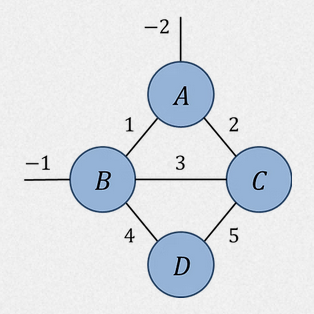

In the example below the output has two open indices, labelled `-1` and `-2`, so the result is a matrix.

In [4]:
# Warm-up tensors.
# The dimensions are deliberately small so that students can inspect shapes.
d = 4
A = np.random.rand(d, d, d)
B = np.random.rand(d, d, d, d)
C = np.random.rand(d, d, d)
D = np.random.rand(d, d)

# Network:
# A_{i, beta, j} B_{alpha, i, k, l} C_{m, k, j} D_{l, m}
#
# Positive labels 1,2,3,4,5 are contracted.
# Negative labels -1 and -2 remain open.
TensorArray = [A, B, C, D]
IndexArray = [
    [1, -2, 2],      # A
    [-1, 1, 3, 4],   # B
    [5, 3, 2],       # C
    [4, 5],          # D
]

E = ncon(TensorArray, IndexArray, cont_order=[5, 3, 4, 1, 2])

print("Shape of the final tensor:", E.shape)
print("The open labels are [-1, -2], so E is a matrix of shape (d, d).")


Shape of the final tensor: (4, 4)
The open labels are [-1, -2], so E is a matrix of shape (d, d).


# 2. Applying a two-site gate to a canonical MPS

We use a two-site unit cell, with tensors ordered as

\[
\cdots \Lambda_{BA} A \Lambda_{AB} B \Lambda_{BA} A \Lambda_{AB} B \cdots .
\]

The essential iTEBD step is:

1. absorb the surrounding Schmidt weights;
2. apply a two-site gate \(U_{AB}\);
3. reshape the two-site tensor into a matrix;
4. perform an SVD;
5. truncate the bond dimension;
6. divide out the external Schmidt weights to restore the canonical MPS convention.

The two-site gate represents a short real-time or imaginary-time evolution step.

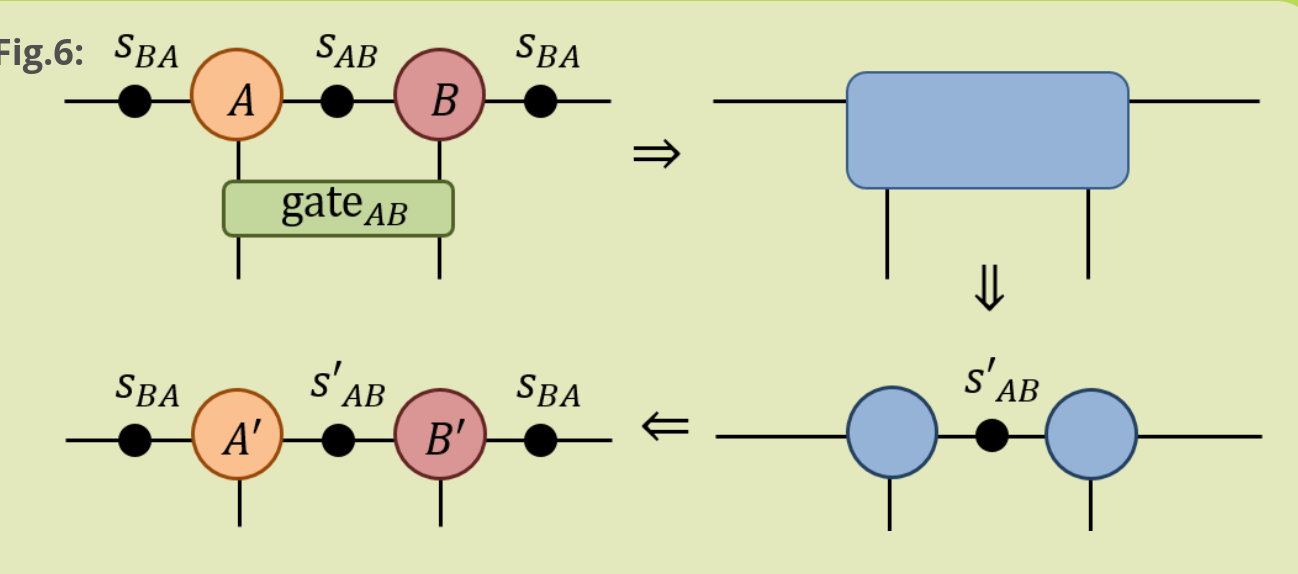

## Exercise 1

Complete the ncon call in the following function which correctly implement the dersired tensor network contraction, rember tensor legs are order as stated in the comment.

In [5]:
def apply_gate_MPS(
    gateAB: np.ndarray,
    A: np.ndarray,
    sAB: np.ndarray,
    B: np.ndarray,
    sBA: np.ndarray,
    chi: int,
    stol: float = 1e-12,
):
    """
    Apply a two-site gate to the A-B bond of a canonical iMPS.

    The local MPS segment is

        sBA -- A -- sAB -- B -- sBA

    and the gate acts on the physical legs of A and B.

    Parameters
    ----------
    gateAB:
        Two-site gate with indices gateAB[a', b', a, b].
        The last two indices are the incoming physical indices, and the
        first two are the outgoing physical indices.
    A, B:
        MPS tensors with shapes (chi_left, d, chi_right).
    sAB:
        Schmidt values on the A-B bond.
    sBA:
        Schmidt values on the B-A bond surrounding the two-site block.
    chi:
        Maximum bond dimension retained after the SVD.
    stol:
        Small floor used when dividing by singular values. This avoids
        numerical divisions by zero.

    Returns
    -------
    A_new, sAB_new, B_new:
        Updated tensors and Schmidt values on the A-B bond.
    """

    # Avoid divisions by extremely small Schmidt values when restoring the
    # canonical form. This does not change the physical state significantly
    # when stol is tiny, but it stabilises the algorithm.
    sBA_safe = np.maximum(sBA, stol)

    d = A.shape[1]
    chiBA = sBA_safe.shape[0]

    # Contract the tensor network
    #
    #   diag(sBA) -- A -- diag(sAB) -- B -- diag(sBA)
    #                   |              |
    #                   ---- gate -----
    #
    # The resulting tensor has open legs:
    #   -1 : left virtual index
    #   -2 : new physical index on A
    #   -3 : new physical index on B
    #   -4 : right virtual index
    tensors = [
        np.diag(sBA_safe),  # left environment Schmidt values
        A,
        np.diag(sAB),       # central A-B Schmidt values
        B,
        np.diag(sBA_safe),  # right environment Schmidt values
        gateAB,
    ]

    connects = [
        [, ],        # left diag(sBA)
        [, , ],      # A: left virtual, physical, right virtual
        [, ],         # diag(sAB)
        [, , ],      # B
        [, ],        # right diag(sBA)
        [, , , ], # gate: outgoing physical legs, incoming physical legs
    ]

    theta = ncon(tensors, connects)

    # Group (left virtual, physical A) as the matrix row index and
    # (physical B, right virtual) as the matrix column index.
    theta_matrix = theta.reshape(d * chiBA, d * chiBA)

    # SVD of the two-site wavefunction.
    utemp, stemp, vhtemp = LA.svd(theta_matrix, full_matrices=False)

    # Truncate the central bond.
    chitemp = min(chi, len(stemp))
    utemp = utemp[:, :chitemp]
    stemp = stemp[:chitemp]
    vhtemp = vhtemp[:chitemp, :]

    # Normalise the retained Schmidt values.
    sAB_new = stemp / LA.norm(stemp)

    # Reshape U and V^\dagger back into MPS tensors.
    #
    # U carries indices (left virtual, physical A, new bond).
    # V carries indices (new bond, physical B, right virtual).
    utemp = utemp.reshape(chiBA, d, chitemp)
    vhtemp = vhtemp.reshape(chitemp, d, chiBA)

    # Remove the external Schmidt weights. This brings the tensors back to
    # the canonical convention used by this implementation.
    A_new = ncon([np.diag(1.0 / sBA_safe), utemp], [[-1, 1], [1, -2, -3]])
    B_new = ncon([vhtemp, np.diag(1.0 / sBA_safe)], [[-1, -2, 1], [1, -3]])

    return A_new, sAB_new, B_new


SyntaxError: invalid syntax (692303638.py, line 72)

# 3. Local density matrices and observables

For a canonical infinite MPS, local expectation values are obtained from reduced density matrices. For a two-site unit cell we need two reduced density matrices:

\[
\rho_{AB}, \qquad \rho_{BA}.
\]

A two-site operator \(O\) is then measured as

\[
\langle O\rangle_{AB} = \mathrm{Tr}(O\,\rho_{AB}),
\]

with the same index ordering as the Hamiltonian tensor.

## Exercise 2

Inspect the contraction below and draw the corresponding tensor network diagarm

In [6]:
def loc_density_MPS(A: np.ndarray, sAB: np.ndarray, B: np.ndarray, sBA: np.ndarray):
    """
    Compute the two local two-site reduced density matrices of a canonical iMPS.

    Returns
    -------
    rhoAB, rhoBA:
        Two-site reduced density matrices with indices
        rho[pA, pB, pA', pB'].
        The first two indices correspond to the bra/output physical legs and
        the last two to the ket/input physical legs, following the convention
        used for the local Hamiltonian tensor.
    """

    mAB = np.diag(sAB)
    mBA = np.diag(sBA)

    # rhoAB: environment sBA^2, then A -- sAB -- B, then environment sBA^2.
    # A and A.conj() are contracted over virtual indices, leaving their
    # physical legs open. The same is done for B.
    tensors = [
        np.diag(sBA**2),
        A,
        A.conj(),
        mAB,
        mAB,
        B,
        B.conj(),
        np.diag(sBA**2),
    ]
    connects = [
        [3, 4],
        [3, -3, 1],
        [4, -1, 2],
        [1, 7],
        [2, 8],
        [7, -4, 5],
        [8, -2, 6],
        [5, 6],
    ]
    rhoAB = ncon(tensors, connects)

    # rhoBA: same contraction, shifted by one site.
    tensors = [
        np.diag(sAB**2),
        B,
        B.conj(),
        mBA,
        mBA,
        A,
        A.conj(),
        np.diag(sAB**2),
    ]
    connects = [
        [3, 4],
        [3, -3, 1],
        [4, -1, 2],
        [1, 7],
        [2, 8],
        [7, -4, 5],
        [8, -2, 6],
        [5, 6],
    ]
    rhoBA = ncon(tensors, connects)

    return rhoAB, rhoBA


def two_site_expectation(operator: np.ndarray, rho: np.ndarray) -> complex:
    """Return Tr(operator rho) for tensors with four physical indices."""
    return ncon([operator, rho], [[1, 2, 3, 4], [1, 2, 3, 4]])


def entanglement_entropy_from_singular_values(s: np.ndarray, base: float = np.e) -> float:
    """
    Von Neumann entanglement entropy from Schmidt values.

    The eigenvalues of the reduced density matrix are p_i = s_i^2.
    """
    p = np.asarray(s, dtype=float) ** 2
    p = p[p > 1e-14]
    return float(-np.sum(p * np.log(p)) / np.log(base))


# 4. The TEBD loop

For a nearest-neighbour Hamiltonian

\[
H = \sum_j h_{j,j+1},
\]

we split the terms into even and odd bonds. A first-order Trotter step is

\[
e^{-i \Delta t H} \simeq e^{-i\Delta t H_{\mathrm{odd}}}
e^{-i\Delta t H_{\mathrm{even}}},
\]

while a second-order step is

\[
e^{-i \Delta t H} \simeq
e^{-i\Delta t H_{\mathrm{even}}/2}
e^{-i\Delta t H_{\mathrm{odd}}}
e^{-i\Delta t H_{\mathrm{even}}/2}.
\]

The function below supports both options. The default is second order, which is usually the better pedagogical choice because the Trotter error is \(O(\Delta t^3)\) per step instead of \(O(\Delta t^2)\).

For real-time evolution we use the convention

\[
U(\Delta t)=e^{-i\Delta t H}.
\]

Changing the sign corresponds to evolving backwards in time. 

In [5]:
def make_two_site_gate(
    h_two_site: np.ndarray,
    tau: float,
    evotype: Literal["real", "imag"] = "real",
) -> np.ndarray:
    """
    Exponentiate a two-site Hamiltonian term.

    h_two_site has shape (d, d, d, d) and is reshaped to a d^2 x d^2 matrix
    before exponentiation.
    """
    d = h_two_site.shape[0]
    h_matrix = h_two_site.reshape(d**2, d**2)

    if evotype == "real":
        gate = expm(-1j * tau * h_matrix)
    elif evotype == "imag":
        gate = expm(-tau * h_matrix)
    else:
        raise ValueError("evotype must be either 'real' or 'imag'.")

    return gate.reshape(d, d, d, d)


def doTEBD(
    hamAB: np.ndarray,
    hamBA: np.ndarray,
    A: np.ndarray,
    B: np.ndarray,
    sAB: np.ndarray,
    sBA: np.ndarray,
    chi: int,
    tau: float,
    evotype: Literal["real", "imag"] = "real",
    numiter: int = 100,
    order: Literal[1, 2] = 2,
    observable: Optional[np.ndarray] = None,
):
    """
    Infinite TEBD for a two-site unit cell.

    Parameters
    ----------
    hamAB, hamBA:
        Local Hamiltonian terms on the A-B and B-A bonds.
    A, B, sAB, sBA:
        Initial canonical iMPS tensors and Schmidt values.
    chi:
        Maximum bond dimension.
    tau:
        Time step.
    evotype:
        'real' for unitary time evolution, 'imag' for imaginary-time evolution.
    numiter:
        Number of TEBD steps.
    order:
        1 for first-order Trotter, 2 for second-order Trotter.
    observable:
        Optional two-site operator measured on the A-B bond at every step.

    Returns
    -------
    A, B, sAB, sBA, rhoAB, rhoBA, times, energies, spectra, obs_values
    """

    if order not in (1, 2):
        raise ValueError("Only first-order and second-order Trotter steps are implemented.")

    # Gates used by the Trotter decomposition.
    if order == 1:
        gateAB = make_two_site_gate(hamAB, tau, evotype)
        gateBA = make_two_site_gate(hamBA, tau, evotype)
    else:
        gateAB_half = make_two_site_gate(hamAB, tau / 2.0, evotype)
        gateBA = make_two_site_gate(hamBA, tau, evotype)

    times = []
    energies = []
    spectra = []
    obs_values = []

    def record(step: int):
        """Measure observables at the current TEBD step."""
        rhoAB, rhoBA = loc_density_MPS(A, sAB, B, sBA)

        energyAB = two_site_expectation(hamAB, rhoAB)
        energyBA = two_site_expectation(hamBA, rhoBA)
        energy = 0.5 * (energyAB + energyBA)

        obs = np.nan
        if observable is not None:
            obs = two_site_expectation(observable, rhoAB)

        times.append(step * tau)
        energies.append(np.real_if_close(energy))
        spectra.append(sAB.copy())
        obs_values.append(np.real_if_close(obs))

        return rhoAB, rhoBA

    # Record the initial state before applying any gate.
    rhoAB, rhoBA = record(0)

    for step in range(1, numiter + 1):
        if order == 1:
            # First-order brick-wall evolution:
            # AB full step, followed by BA full step.
            A, sAB, B = apply_gate_MPS(gateAB, A, sAB, B, sBA, chi)
            B, sBA, A = apply_gate_MPS(gateBA, B, sBA, A, sAB, chi)
        else:
            # Second-order symmetric step:
            # AB half step, BA full step, AB half step.
            A, sAB, B = apply_gate_MPS(gateAB_half, A, sAB, B, sBA, chi)
            B, sBA, A = apply_gate_MPS(gateBA, B, sBA, A, sAB, chi)
            A, sAB, B = apply_gate_MPS(gateAB_half, A, sAB, B, sBA, chi)

        rhoAB, rhoBA = record(step)

    return (
        A,
        B,
        sAB,
        sBA,
        rhoAB,
        rhoBA,
        np.asarray(times),
        np.asarray(energies),
        spectra,
        np.asarray(obs_values),
    )


# 5. Example: quench in the transverse-field Ising chain

Here we use the local Hamiltonian

\[
h_{j,j+1} =
\sigma^x_j\sigma^x_{j+1}
+\frac{\lambda}{2}\left(\sigma^z_j+\sigma^z_{j+1}\right).
\]

The factor \(1/2\) avoids double-counting the field when summing over nearest-neighbour bonds. With this convention, the critical point is at \(|\lambda|=1\) up to the overall sign convention for the Hamiltonian.

The initial state below is the product state \(|0\,0\,0\cdots\rangle\), which is simple to encode as an iMPS with bond dimension one.

In [2]:
# Simulation parameters.
chi = 30         # maximum bond dimension kept after each SVD
tau = 0.1         # time step
numiter = 50       # number of time steps
evotype = "real"   # "real" or "imag"
trotter_order = 2  # 1 or 2

# Pauli matrices.
sX = np.array([[0, 1], [1, 0]], dtype=complex)
sZ = np.array([[1, 0], [0, -1]], dtype=complex)
Id = np.eye(2, dtype=complex)

# Transverse-field Ising coupling.
lambda_field = 1.0

ham_two_site = (
    np.kron(sX, sX)
    + 0.5 * lambda_field * (np.kron(sZ, Id) + np.kron(Id, sZ))
).reshape(2, 2, 2, 2)

# Homogeneous two-site unit cell: same Hamiltonian on AB and BA bonds.
hamAB = ham_two_site
hamBA = ham_two_site

# Two-site observable measuring the average sigma_z on the A-B bond.
mag_z_AB = 0.5 * (np.kron(sZ, Id) + np.kron(Id, sZ)).reshape(2, 2, 2, 2)

# Initial product state |0 0 0 ...>.
d = 2
A = np.zeros((1, d, 1), dtype=complex)
B = np.zeros((1, d, 1), dtype=complex)
A[0, 0, 0] = 1.0
B[0, 0, 0] = 1.0

sAB = np.ones(1)
sBA = np.ones(1)

# Run the TEBD routine.
(
    A,
    B,
    sAB,
    sBA,
    rhoAB,
    rhoBA,
    times,
    list_ene,
    list_ent_spe,
    list_mag,
) = doTEBD(
    hamAB,
    hamBA,
    A,
    B,
    sAB,
    sBA,
    chi=chi,
    tau=tau,
    evotype=evotype,
    numiter=numiter,
    order=trotter_order,
    observable=mag_z_AB,
)

energyMPS = np.real(
    0.5 * two_site_expectation(hamAB, rhoAB)
    + 0.5 * two_site_expectation(hamBA, rhoBA)
)

print(f"Final bond dimension on AB bond: {len(sAB)}")
print(f"Final energy density: {energyMPS:.12f}")
print(f"Energy drift: {np.real(list_ene[-1] - list_ene[0]):.3e}")


NameError: name 'np' is not defined

# 6. Plotting and interpretation

The following plots are the first diagnostic checks of the simulation.

1. **Energy drift**: for real-time evolution the energy should be approximately conserved. The remaining drift comes from Trotter error and bond-dimension truncation.
2. **Entanglement entropy**: after a global quench, entanglement typically grows, making the simulation progressively harder.
3. **Entanglement spectrum**: we plot \(-\log(s_i^2)\), where \(s_i\) are the Schmidt values. This is the spectrum of the entanglement Hamiltonian up to an additive convention.
4. **Magnetisation**: the local observable \(\langle \sigma^z\rangle\) after the quench.

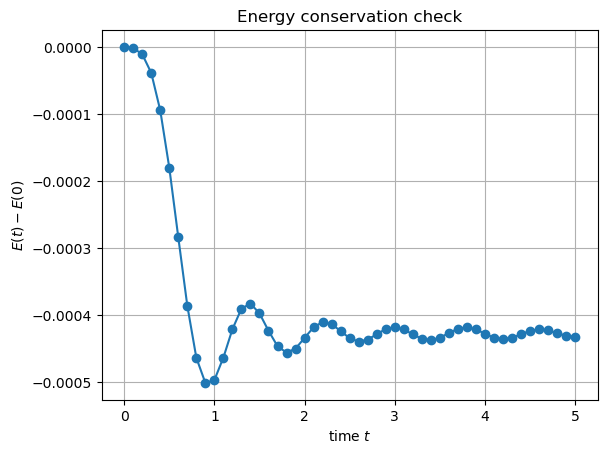

In [7]:
# Energy drift.
plt.figure()
plt.plot(times, np.real(list_ene - list_ene[0]), "o-")
plt.xlabel(r"time $t$")
plt.ylabel(r"$E(t)-E(0)$")
plt.title("Energy conservation check")
plt.grid(True)
plt.show()


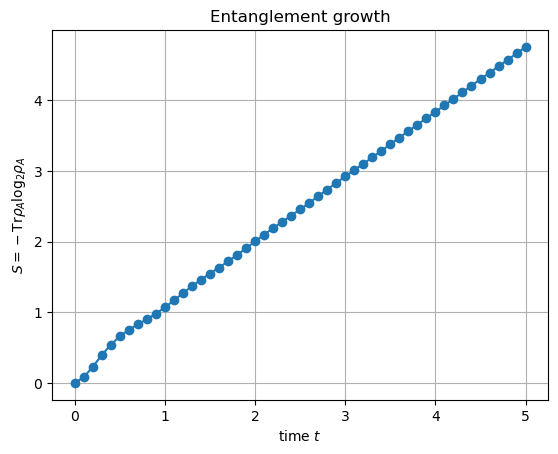

In [8]:
# Entanglement entropy.
entropies = np.array([
    entanglement_entropy_from_singular_values(s, base=2)
    for s in list_ent_spe
])

plt.figure()
plt.plot(times, entropies, "o-")
plt.xlabel(r"time $t$")
plt.ylabel(r"$S=-\mathrm{Tr}\rho_A\log_2\rho_A$")
plt.title("Entanglement growth")
plt.grid(True)
plt.show()


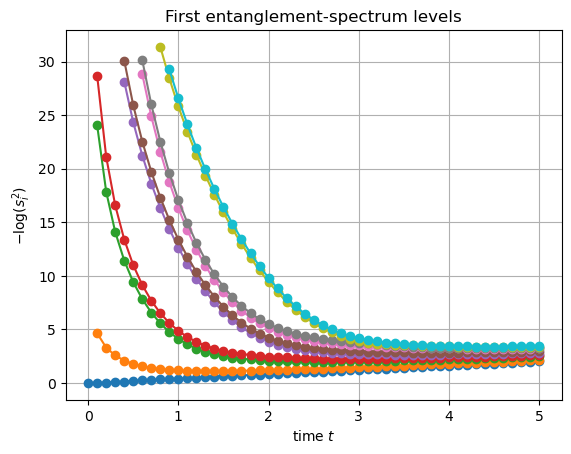

In [9]:
# Entanglement spectrum: epsilon_i = -log(s_i^2).
num_levels = 10

levels = np.full((len(list_ent_spe), num_levels), np.nan)
for k, s in enumerate(list_ent_spe):
    p = np.asarray(s[:num_levels]) ** 2
    p[p < 1e-14] = np.nan
    levels[k, :len(p)] = -np.log(p)

plt.figure()
plt.plot(times, levels, "o-")
plt.xlabel(r"time $t$")
plt.ylabel(r"$-\log(s_i^2)$")
plt.title("First entanglement-spectrum levels")
plt.grid(True)
plt.show()


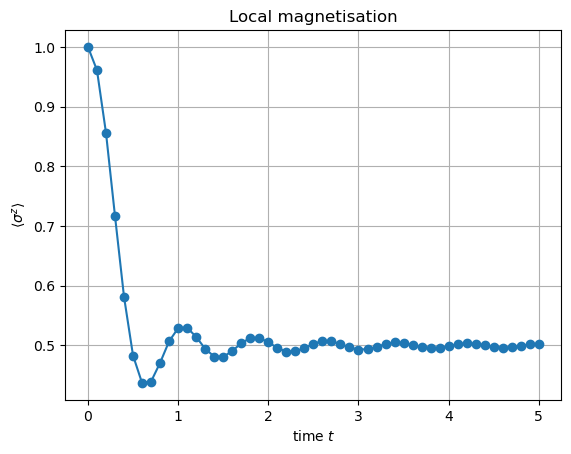

In [10]:
# Magnetisation.
plt.figure()
plt.plot(times, np.real(list_mag), "o-")
plt.xlabel(r"time $t$")
plt.ylabel(r"$\langle \sigma^z\rangle$")
plt.title("Local magnetisation")
plt.grid(True)
plt.show()


## Discussion questions

- What happens to the energy drift when you reduce `tau`?
- What happens to the entanglement growth when you increase `chi`?
- Does the entanglement spectrum show a clear hierarchy of singular values?
- At what time does the finite bond dimension begin to affect the observables?
- Compare first-order and second-order Trotter evolution by changing `trotter_order`.